
Processing displacement-distribution system: PE-A1
Reading displacement file: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica1/linear.lammpstrj
  replica = 1
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
    displacement lag 1 ps : count = 240000
    displacement lag 10 ps : count = 237840
    displacement lag 100 ps : count = 216240
Reading displacement file: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica2/linear.lammpstrj
  replica = 2
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
    displacement lag 1 ps : count = 240000
    displacement lag 10 ps : count = 237840
    displacement lag 100 ps : count = 216240
Reading displacement file: /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica3/linear.lammpstrj
  replica = 3
  selected atom type = 10
  frames read = 1001
  atoms/frame = 240
  first timestep = 0, last timestep = 1000000
   

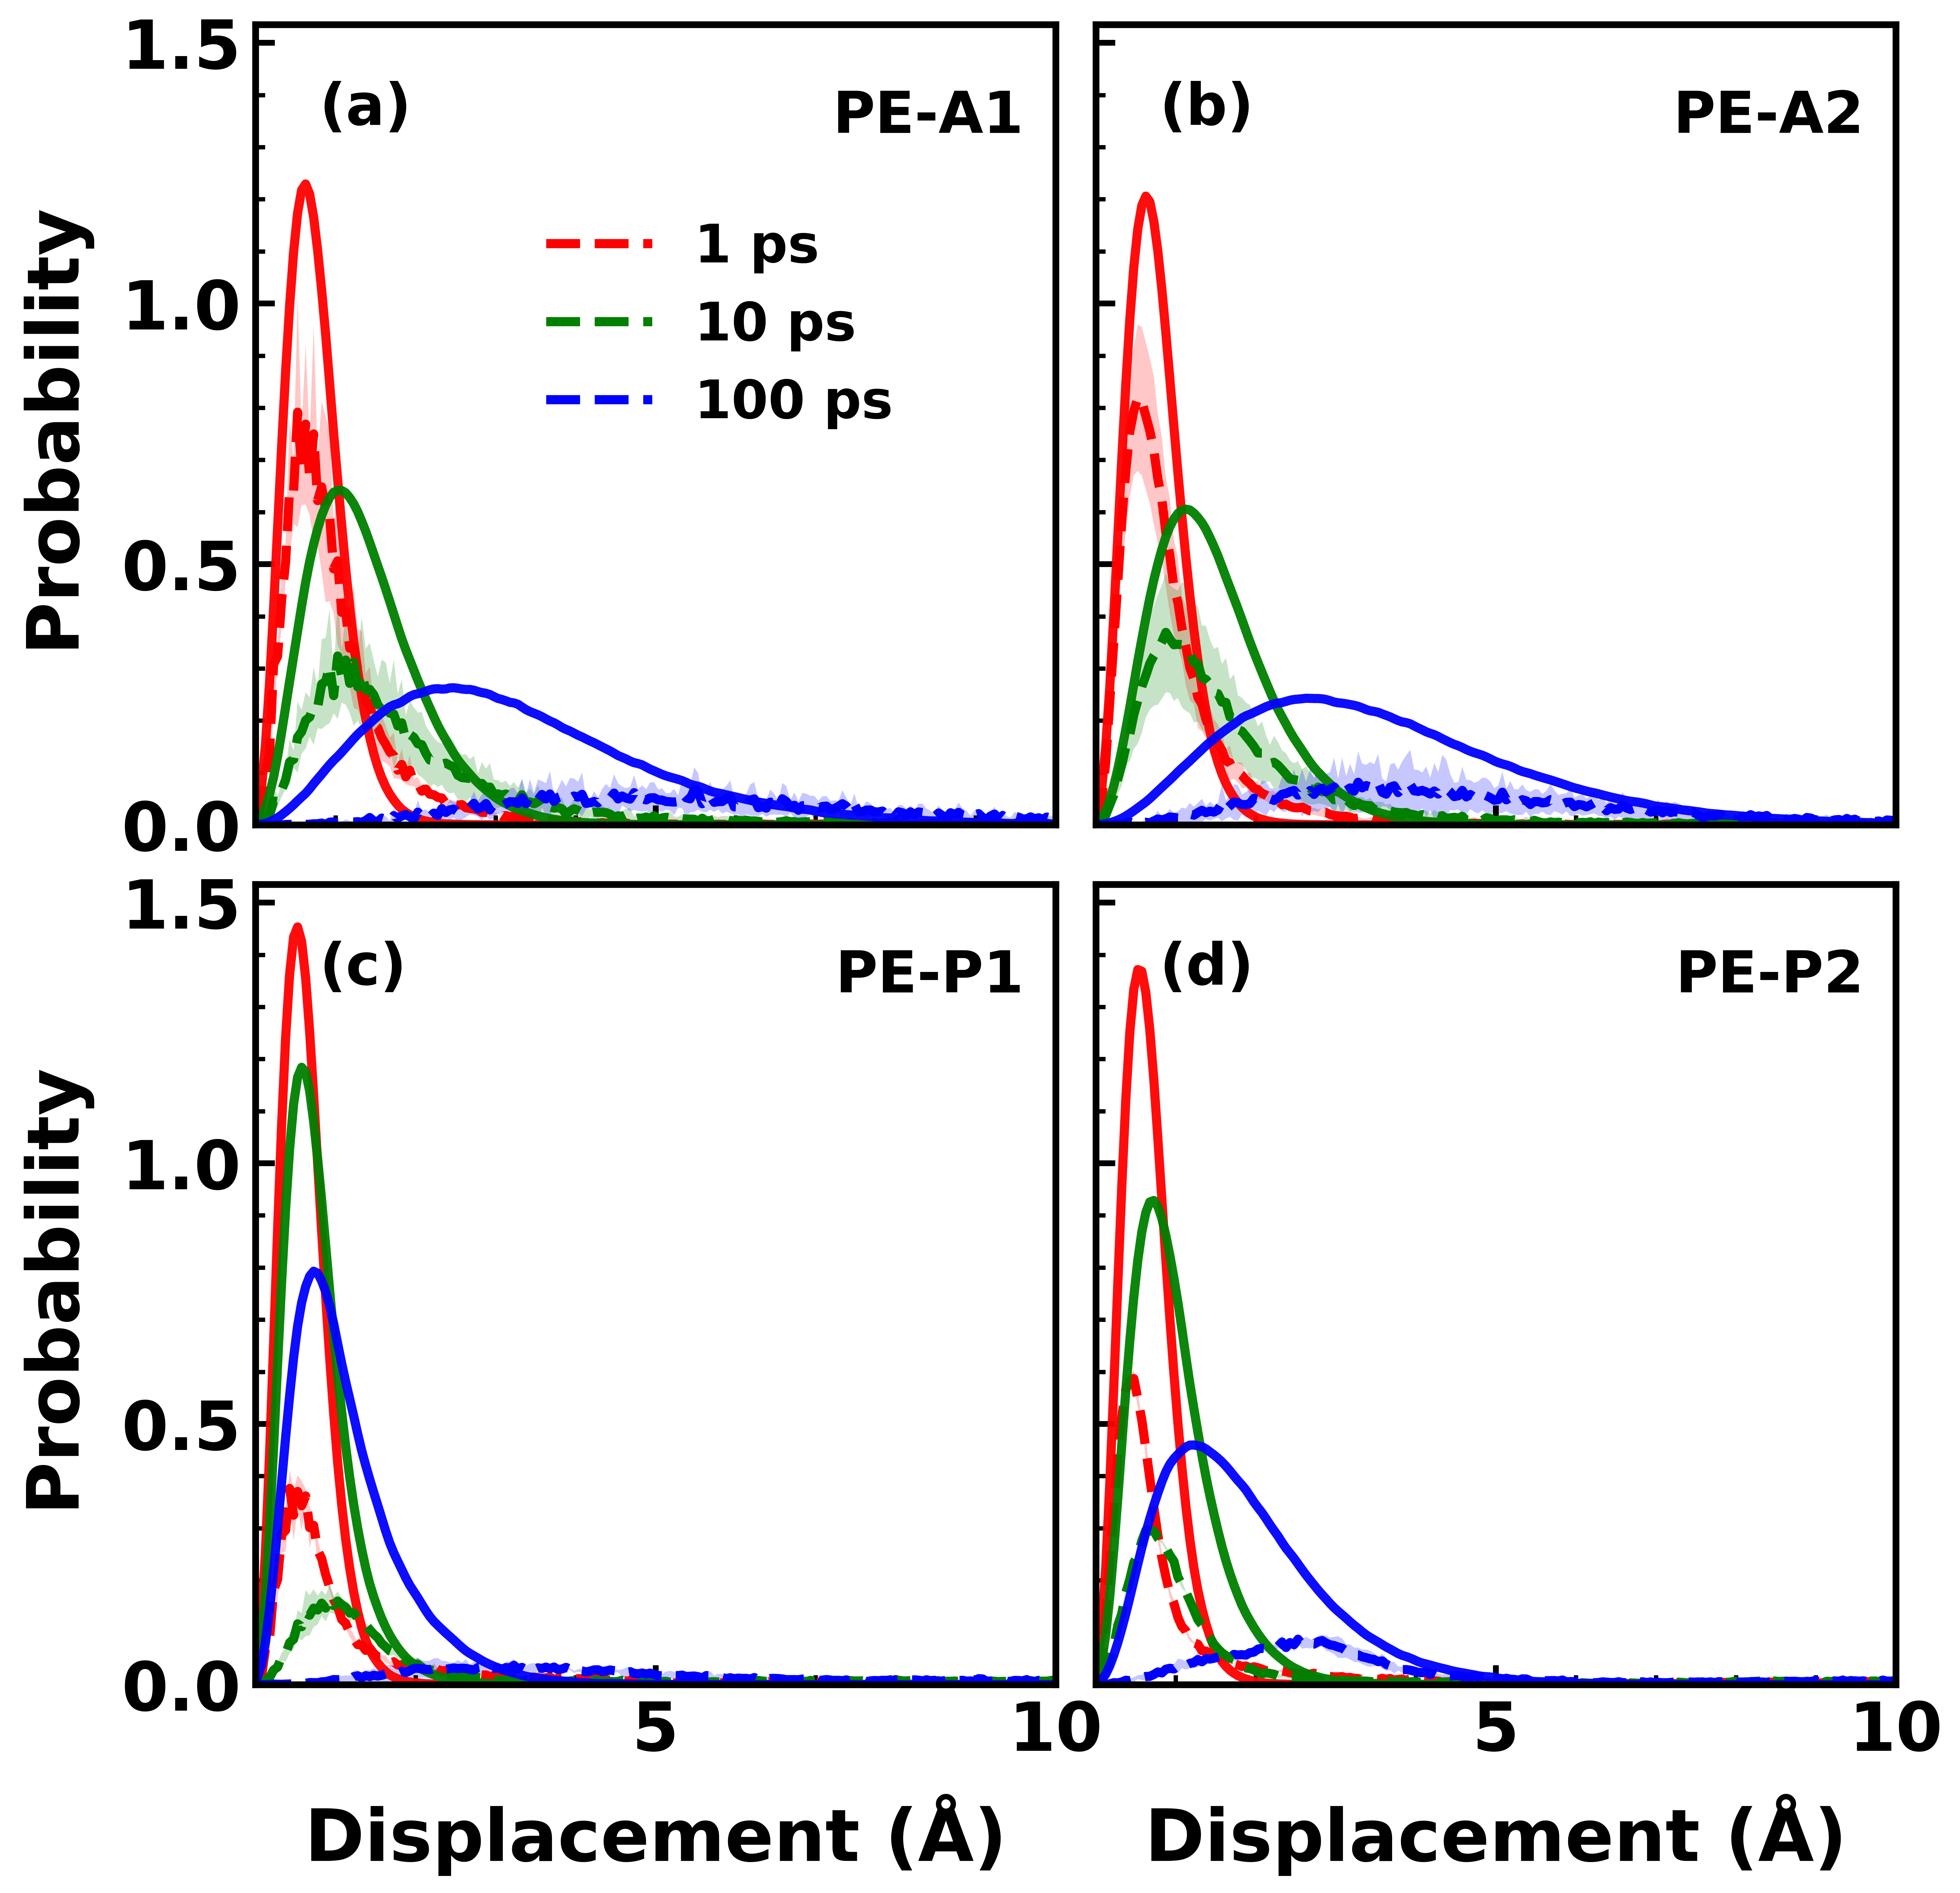


Saved:
combined_displacement_vanhove_2x2_ACSbold_overlay.png
combined_displacement_vanhove_2x2_ACSbold_overlay.pdf

In this plot:
  solid line + shaded band = displacement distribution
  dashed line              = Van Hove distribution


In [ ]:
#!/usr/bin/env python3

import os
import fileinput
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d

# =========================================================
# SETTINGS
# =========================================================
BASE_DISP = "/blue/jsampath/avemula/Paper1_PE/Polymer"
BASE_VH   = "/blue/jsampath/avemula/Paper1_PE/Classical"

SYSTEMS_DISP = {
    "PE-A1": {
        "atom_type": 10,
        "files": [
            f"{BASE_DISP}/PE_A1/Replica1/linear.lammpstrj",
            f"{BASE_DISP}/PE_A1/Replica2/linear.lammpstrj",
            f"{BASE_DISP}/PE_A1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-A2": {
        "atom_type": 9,
        "files": [
            f"{BASE_DISP}/PE_A2/Replica1/linear.lammpstrj",
            f"{BASE_DISP}/PE_A2/Replica2/linear.lammpstrj",
            f"{BASE_DISP}/PE_A2/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P1": {
        "atom_type": 10,
        "files": [
            f"{BASE_DISP}/PE_P1/Replica1/linear.lammpstrj",
            f"{BASE_DISP}/PE_P1/Replica2/linear.lammpstrj",
            f"{BASE_DISP}/PE_P1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P2": {
        "atom_type": 9,
        "files": [
            f"{BASE_DISP}/PE_P2/Replica1/linear.lammpstrj",
            f"{BASE_DISP}/PE_P2/Replica2/linear.lammpstrj",
            f"{BASE_DISP}/PE_P2/Replica3/linear.lammpstrj",
        ],
    },
}

SYSTEMS_VH = {
    "PE-A1": {
        "atom_type": 10,
        "files": [
            f"{BASE_VH}/PE_A1/Replica1/linear.lammpstrj",
            f"{BASE_VH}/PE_A1/Replica2/linear.lammpstrj",
            f"{BASE_VH}/PE_A1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-A2": {
        "atom_type": 9,
        "files": [
            f"{BASE_VH}/PE_A2/Replica1/linear.lammpstrj",
            f"{BASE_VH}/PE_A2/Replica2/linear.lammpstrj",
            f"{BASE_VH}/PE_A2/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P1": {
        "atom_type": 10,
        "files": [
            f"{BASE_VH}/PE_P1/Replica1/linear.lammpstrj",
            f"{BASE_VH}/PE_P1/Replica2/linear.lammpstrj",
            f"{BASE_VH}/PE_P1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P2": {
        "atom_type": 9,
        "files": [
            f"{BASE_VH}/PE_P2/Replica1/linear.lammpstrj",
            f"{BASE_VH}/PE_P2/Replica2/linear.lammpstrj",
            f"{BASE_VH}/PE_P2/Replica3/linear.lammpstrj",
        ],
    },
}

TIME_CUTOFF = 1000000
DUMP_EVERY = 1000
TIMESTEP_FS = 1.0
PS_PER_FRAME = (DUMP_EVERY * TIMESTEP_FS) / 1000.0   # for displacement-distribution script

TIME_DIVIDE = 1000.0   # for van hove script, 1000 steps = 1 ps
LAGS_PS = [1, 10, 100]

FILTERED_SUFFIX = "Only_target_type.lammpstrj"

OUT_PNG = "combined_displacement_vanhove_2x2_ACSbold_overlay.png"
OUT_PDF = "combined_displacement_vanhove_2x2_ACSbold_overlay.pdf"

# =========================================================
# AXIS / HISTOGRAM SETTINGS
# =========================================================
XMIN, XMAX = 0, 8
YMIN = 0
BINS = np.linspace(0, 40, 800)
SMOOTH_SIGMA = 1.0

# =========================================================
# PLOT SETTINGS
# =========================================================
LABEL_SIZE = 30
TICK_SIZE = 28
LEGEND_SIZE = 22
PANEL_TAG_SIZE = 24
SYSTEM_TEXT_SIZE = 24

SPINE_W = 2.8
TICK_W_MAJOR = 2.4
TICK_W_MINOR = 1.8
TICK_LEN_MAJOR = 8
TICK_LEN_MINOR = 4

# Displacement distribution (solid + shaded band)
DISP_LINE_W = 3.8
DISP_SHADE_ALPHA = 0.22

# Van Hove (dashed)
VH_LINE_W = 3.8
VH_BAND_SCALE = 1.5   # only used to determine y max
VH_REPLICA_LINEWIDTH = 1.0
VH_REPLICA_ALPHA = 0.18  # not plotted, kept only if you want later

FONT_FAMILY = "DejaVu Sans"

colors = {
    1: "red",
    10: "green",
    100: "blue",
}

labels = {
    1: "1 ps",
    10: "10 ps",
    100: "100 ps",
}

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.labelsize": LABEL_SIZE,
    "axes.labelweight": "bold",
    "axes.titlesize": LABEL_SIZE,
    "axes.titleweight": "bold",
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "axes.linewidth": SPINE_W,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": TICK_LEN_MAJOR,
    "ytick.major.size": TICK_LEN_MAJOR,
    "xtick.major.width": TICK_W_MAJOR,
    "ytick.major.width": TICK_W_MAJOR,
    "xtick.minor.size": TICK_LEN_MINOR,
    "ytick.minor.size": TICK_LEN_MINOR,
    "xtick.minor.width": TICK_W_MINOR,
    "ytick.minor.width": TICK_W_MINOR,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})

# =========================================================
# HELPERS
# =========================================================
def make_ticklabels_bold(ax):
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontfamily(FONT_FAMILY)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontfamily(FONT_FAMILY)

def remove_zero_xtick_label(ax):
    xticks = ax.get_xticks()
    xlabels = []
    for x in xticks:
        if np.isclose(x, 0.0):
            xlabels.append("")
        else:
            xlabels.append(f"{x:g}")
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)

# =========================================================
# PART A: DISPLACEMENT DISTRIBUTION FUNCTIONS
# =========================================================
def read_type_positions_from_lammpstrj(filename, atom_type_keep, time_cutoff=None):
    """
    Reads selected atom type using xu, yu, zu.
    Returns:
        times  : list of timesteps
        frames : list of arrays, shape (n_selected_atoms, 3)
    """
    times = []
    frames = []

    with open(filename, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break

            if not line.startswith("ITEM: TIMESTEP"):
                continue

            timestep = int(f.readline().strip())
            if time_cutoff is not None and timestep > time_cutoff:
                break

            line = f.readline().strip()
            if "NUMBER OF ATOMS" not in line:
                raise RuntimeError(f"Missing NUMBER OF ATOMS in {filename}")

            natoms = int(f.readline().strip())

            line = f.readline().strip()
            if not line.startswith("ITEM: BOX BOUNDS"):
                raise RuntimeError(f"Missing BOX BOUNDS in {filename}")

            f.readline()
            f.readline()
            f.readline()

            atom_header = f.readline().strip()
            if not atom_header.startswith("ITEM: ATOMS"):
                raise RuntimeError(f"Missing ATOMS header in {filename}")

            cols = atom_header.split()[2:]
            col_index = {c: i for i, c in enumerate(cols)}

            required = ["id", "type", "xu", "yu", "zu"]
            for r in required:
                if r not in col_index:
                    raise RuntimeError(f"{filename} missing required column: {r}")

            id_idx   = col_index["id"]
            type_idx = col_index["type"]
            xu_idx   = col_index["xu"]
            yu_idx   = col_index["yu"]
            zu_idx   = col_index["zu"]

            kept = []
            for _ in range(natoms):
                parts = f.readline().split()
                if int(parts[type_idx]) == atom_type_keep:
                    kept.append([
                        int(parts[id_idx]),
                        float(parts[xu_idx]),
                        float(parts[yu_idx]),
                        float(parts[zu_idx]),
                    ])

            if len(kept) == 0:
                continue

            kept = np.array(kept, dtype=float)
            order = np.argsort(kept[:, 0])
            kept = kept[order]

            times.append(timestep)
            frames.append(kept[:, 1:4])

    if len(frames) == 0:
        raise RuntimeError(f"No usable frames found in {filename}")

    nsel = frames[0].shape[0]
    for i, fr in enumerate(frames):
        if fr.shape[0] != nsel:
            raise RuntimeError(
                f"Selected atom count changes across frames in {filename}: "
                f"frame 0 has {nsel}, frame {i} has {fr.shape[0]}"
            )

    return times, frames

def compute_displacement_distributions(frames, lags_ps, ps_per_frame):
    nframes = len(frames)
    results = {}

    for lag_ps in lags_ps:
        lag_frames = int(round(lag_ps / ps_per_frame))

        if lag_frames < 1:
            raise RuntimeError(f"lag_ps={lag_ps} gives lag_frames < 1")
        if nframes <= lag_frames:
            raise RuntimeError(
                f"Not enough frames for {lag_ps} ps displacement: "
                f"need > {lag_frames}, found {nframes}"
            )

        dr_all = []
        for i in range(nframes - lag_frames):
            dxyz = frames[i + lag_frames] - frames[i]
            dr = np.linalg.norm(dxyz, axis=1)
            dr_all.append(dr)

        results[lag_ps] = np.concatenate(dr_all)

    return results

def process_system_displacement(replica_files, atom_type_keep, time_cutoff, lags_ps, ps_per_frame):
    per_replica_results = []

    for rep_idx, repfile in enumerate(replica_files, start=1):
        print(f"Reading displacement file: {repfile}")

        times, frames = read_type_positions_from_lammpstrj(
            repfile,
            atom_type_keep=atom_type_keep,
            time_cutoff=time_cutoff
        )

        print(f"  replica = {rep_idx}")
        print(f"  selected atom type = {atom_type_keep}")
        print(f"  frames read = {len(frames)}")
        print(f"  atoms/frame = {frames[0].shape[0]}")
        print(f"  first timestep = {times[0]}, last timestep = {times[-1]}")

        rep_results = compute_displacement_distributions(
            frames,
            lags_ps=lags_ps,
            ps_per_frame=ps_per_frame
        )

        for lag in lags_ps:
            print(f"    displacement lag {lag} ps : count = {len(rep_results[lag])}")

        per_replica_results.append(rep_results)

    return per_replica_results

def histogram_mean_std_displacement(replica_results_for_one_system, lag_ps, bins):
    hist_list = []

    for rep in replica_results_for_one_system:
        arr = rep[lag_ps]
        hist, edges = np.histogram(arr, bins=bins, density=True)
        hist_list.append(hist)

    hist_array = np.array(hist_list)
    mean_hist = hist_array.mean(axis=0)

    if hist_array.shape[0] > 1:
        std_hist = hist_array.std(axis=0, ddof=1)
    else:
        std_hist = np.zeros_like(mean_hist)

    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, mean_hist, std_hist

# =========================================================
# PART B: VAN HOVE FUNCTIONS
# =========================================================
def filter_trajectory(input_traj, atom_type_to_keep):
    outdir = os.path.dirname(input_traj)
    filtered_traj = os.path.join(outdir, FILTERED_SUFFIX)

    print(f"\nFiltering file:\n  {input_traj}")
    print(f"Output filtered file:\n  {filtered_traj}")

    with open(filtered_traj, "w") as OUT:
        IN = fileinput.input([input_traj])

        while True:
            headers = [IN.readline() for _ in range(9)]
            if any(h == "" for h in headers):
                break

            try:
                natoms = int(headers[3].strip())
            except ValueError:
                raise RuntimeError(f"Could not parse NUMBER OF ATOMS in file: {input_traj}")

            kept_atoms = []
            for _ in range(natoms):
                line = IN.readline()
                if line == "":
                    raise RuntimeError(f"Unexpected EOF inside atom block in file: {input_traj}")

                parts = line.split()
                if len(parts) < 3:
                    raise RuntimeError(f"Malformed atom line in {input_traj}:\n{line}")

                typ = int(parts[2])
                if typ == atom_type_to_keep:
                    kept_atoms.append(line)

            OUT.writelines(headers[:3])
            OUT.write(f"{len(kept_atoms)}\n")
            OUT.writelines(headers[4:])
            for atom_line in kept_atoms:
                OUT.write(atom_line)

    print(f"Done filtering: {filtered_traj}")
    return filtered_traj

def read_filtered_traj(filtered_traj, time_cutoff, time_divide):
    """
    Reads filtered trajectory with columns:
    ITEM: ATOMS id mol type x y z xu yu zu
    """
    col_names = ["id", "mol", "type", "x", "y", "z", "xu", "yu", "zu"]

    with open(filtered_traj, "r") as f:
        lines = f.readlines()

    if len(lines) < 9:
        raise RuntimeError(f"Filtered trajectory is too short or empty: {filtered_traj}")

    data = []
    num_particles = None

    for i in range(len(lines)):
        if "ITEM: TIMESTEP" in lines[i]:
            timestep = int(lines[i + 1])

            if timestep > time_cutoff:
                break

            num_particles = int(lines[i + 3].strip())

            for j in range(i + 9, i + 9 + num_particles):
                parts = lines[j].split()
                if len(parts) < 9:
                    continue

                particle_id, mol, particle_type, x, y, z, xu, yu, zu = parts[:9]
                data.append([
                    timestep,
                    particle_id,
                    mol,
                    particle_type,
                    x, y, z, xu, yu, zu
                ])

    df = pd.DataFrame(data, columns=["time"] + col_names)

    if df.empty:
        raise RuntimeError(f"No data found in filtered file: {filtered_traj}")

    df[["id", "mol", "type"]] = df[["id", "mol", "type"]].astype(int)
    df[["x", "y", "z", "xu", "yu", "zu"]] = df[["x", "y", "z", "xu", "yu", "zu"]].astype(float)
    df["time"] = df["time"].astype(int) / time_divide

    df["xa"] = df["xu"]
    df["ya"] = df["yu"]
    df["za"] = df["zu"]

    df = df.sort_values(["time", "id"]).reset_index(drop=True)
    times = np.sort(df["time"].unique())

    if len(times) < 2:
        raise RuntimeError(f"Not enough frames in {filtered_traj}")

    dt_ps = times[1] - times[0]

    print(f"Read filtered file: {filtered_traj}")
    print("DataFrame shape:", df.shape)
    print("num_particles =", num_particles)
    print("first few times =", times[:10], "...")
    print("Frame spacing (ps) =", dt_ps)

    return df, times, dt_ps, num_particles

def collect_displacements_for_lag(df, times, lag_ps, time_tol=1e-8):
    out = []
    time_set = set(np.round(times, 8))

    for t0 in times:
        t1 = t0 + lag_ps

        if np.round(t1, 8) not in time_set:
            continue

        f0 = df[np.isclose(df["time"], t0, atol=time_tol)].sort_values("id").reset_index(drop=True)
        f1 = df[np.isclose(df["time"], t1, atol=time_tol)].sort_values("id").reset_index(drop=True)

        ids0 = f0["id"].to_numpy()
        ids1 = f1["id"].to_numpy()

        common_ids, idx0, idx1 = np.intersect1d(
            ids0, ids1,
            assume_unique=False,
            return_indices=True
        )

        if len(common_ids) == 0:
            continue

        r0 = f0.loc[idx0, ["xa", "ya", "za"]].to_numpy()
        r1 = f1.loc[idx1, ["xa", "ya", "za"]].to_numpy()

        dr_vec = r1 - r0

        # drift correction
        drift = dr_vec.mean(axis=0)
        dr_vec = dr_vec - drift

        dr = np.linalg.norm(dr_vec, axis=1)
        dr = dr[np.isfinite(dr)]

        if dr.size > 0:
            out.append(dr)

    if len(out) == 0:
        raise RuntimeError(f"No displacements found for lag {lag_ps} ps")

    return np.concatenate(out)

def process_system_vanhove(replica_files, atom_type_keep, time_cutoff, lags_ps, time_divide):
    per_replica_results = []

    for rep_idx, repfile in enumerate(replica_files, start=1):
        print(f"Reading Van Hove file: {repfile}")

        filtered_traj = filter_trajectory(repfile, atom_type_keep)

        df, times, dt_ps, num_particles = read_filtered_traj(
            filtered_traj,
            time_cutoff=time_cutoff,
            time_divide=time_divide
        )

        rep_results = {}

        print(f"  replica = {rep_idx}")
        print(f"  selected atom type = {atom_type_keep}")
        print(f"  frames read = {len(times)}")
        print(f"  atoms/frame = {num_particles}")
        print(f"  first time = {times[0]}, last time = {times[-1]}")

        for lag in lags_ps:
            ratio = lag / dt_ps
            if not np.isclose(ratio, round(ratio), atol=1e-8):
                raise RuntimeError(
                    f"lag {lag} ps is not an integer multiple of frame spacing {dt_ps} ps"
                )

            dr = collect_displacements_for_lag(df, times, lag_ps=lag)
            rep_results[lag] = dr
            print(f"    Van Hove lag {lag} ps : count = {len(dr)}")

        per_replica_results.append(rep_results)

    return per_replica_results

def histogram_mean_std_vanhove(replica_results_for_one_system, lag_ps, bins):
    hist_list = []

    for rep in replica_results_for_one_system:
        arr = rep[lag_ps]
        hist, edges = np.histogram(arr, bins=bins, density=True)
        hist = gaussian_filter1d(hist, sigma=SMOOTH_SIGMA)
        hist_list.append(hist)

    hist_array = np.array(hist_list)
    mean_hist = hist_array.mean(axis=0)

    if hist_array.shape[0] > 1:
        std_hist = hist_array.std(axis=0, ddof=1)
    else:
        std_hist = np.zeros_like(mean_hist)

    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, mean_hist, std_hist

# =========================================================
# MAIN
# =========================================================
def main():
    all_results_disp = {}
    all_results_vh = {}

    # -------------------------
    # Displacement distributions
    # -------------------------
    for sys_name, info in SYSTEMS_DISP.items():
        print("\n" + "=" * 80)
        print(f"Processing displacement-distribution system: {sys_name}")
        print("=" * 80)

        all_results_disp[sys_name] = process_system_displacement(
            replica_files=info["files"],
            atom_type_keep=info["atom_type"],
            time_cutoff=TIME_CUTOFF,
            lags_ps=LAGS_PS,
            ps_per_frame=PS_PER_FRAME
        )

    # -------------------------
    # Van Hove distributions
    # -------------------------
    for sys_name, info in SYSTEMS_VH.items():
        print("\n" + "=" * 80)
        print(f"Processing Van Hove system: {sys_name}")
        print("=" * 80)

        all_results_vh[sys_name] = process_system_vanhove(
            replica_files=info["files"],
            atom_type_keep=info["atom_type"],
            time_cutoff=TIME_CUTOFF,
            lags_ps=LAGS_PS,
            time_divide=TIME_DIVIDE
        )

    # -------------------------
    # Determine common y max
    # -------------------------
    ymax_list = []

    system_order = ["PE-A1", "PE-A2", "PE-P1", "PE-P2"]

    for sys_name in system_order:
        disp_replica_results = all_results_disp[sys_name]
        vh_replica_results = all_results_vh[sys_name]

        for lag in LAGS_PS:
            c1, m1, s1 = histogram_mean_std_displacement(
                replica_results_for_one_system=disp_replica_results,
                lag_ps=lag,
                bins=BINS
            )
            ymax_list.append(np.max(m1 + s1))

            c2, m2, s2 = histogram_mean_std_vanhove(
                replica_results_for_one_system=vh_replica_results,
                lag_ps=lag,
                bins=BINS
            )
            ymax_list.append(np.max(m2 + VH_BAND_SCALE * s2))

    ymax = max(1.0, 1.05 * max(ymax_list))

    # -------------------------
    # Plot
    # -------------------------
    fig, axes = plt.subplots(
        2, 2,
        figsize=(11, 11),
        dpi=600,
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()
    panel_tags = ["(a)", "(b)", "(c)", "(d)"]

    for i, (ax, sys_name) in enumerate(zip(axes, system_order)):
        disp_replica_results = all_results_disp[sys_name]
        vh_replica_results = all_results_vh[sys_name]

        for lag in LAGS_PS:
            # -------------------------
            # Displacement distribution
            # solid line + shaded std
            # -------------------------
            centers_disp, mean_disp, std_disp = histogram_mean_std_displacement(
                replica_results_for_one_system=disp_replica_results,
                lag_ps=lag,
                bins=BINS
            )

            ax.fill_between(
                centers_disp,
                np.clip(mean_disp - std_disp, 0, None),
                mean_disp + std_disp,
                color=colors[lag],
                alpha=DISP_SHADE_ALPHA,
                linewidth=0
            )

            ax.plot(
                centers_disp,
                mean_disp,
                lw=DISP_LINE_W,
                color=colors[lag],
                linestyle="--",
                label=labels[lag] if i == 0 else None
            )

            # -------------------------
            # Van Hove distribution
            # dashed line only
            # -------------------------
            centers_vh, mean_vh, std_vh = histogram_mean_std_vanhove(
                replica_results_for_one_system=vh_replica_results,
                lag_ps=lag,
                bins=BINS
            )

            ax.plot(
                centers_vh,
                mean_vh,
                lw=VH_LINE_W,
                color=colors[lag],
                linestyle="-",
                alpha=0.95
            )

        ax.set_xlim(XMIN, XMAX)
        ax.set_ylim(YMIN, ymax)

        ax.text(
            0.08, 0.93, panel_tags[i],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=PANEL_TAG_SIZE,
            fontweight="bold"
        )

        ax.text(
            0.96, 0.92, sys_name,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=SYSTEM_TEXT_SIZE,
            fontweight="bold"
        )

        ax.tick_params(
            axis="both",
            which="major",
            direction="in",
            labelsize=TICK_SIZE,
            width=TICK_W_MAJOR,
            length=TICK_LEN_MAJOR,
            top=False,
            right=False,
            pad=6
        )

        ax.tick_params(
            axis="both",
            which="minor",
            direction="in",
            width=TICK_W_MINOR,
            length=TICK_LEN_MINOR,
            top=False,
            right=False
        )

        ax.minorticks_on()

        for spine in ax.spines.values():
            spine.set_linewidth(SPINE_W)

        make_ticklabels_bold(ax)
        ax.set_box_aspect(1)

    # Left column y-labels only
    axes[0].set_ylabel("Probability", fontsize=LABEL_SIZE, fontweight="bold", labelpad=14)
    axes[2].set_ylabel("Probability", fontsize=LABEL_SIZE, fontweight="bold", labelpad=14)

    # Bottom row x-labels only
    axes[2].set_xlabel("Displacement (Å)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=12)
    axes[3].set_xlabel("Displacement (Å)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=12)

    # Hide top-row x tick labels
    axes[0].tick_params(labelbottom=False)
    axes[1].tick_params(labelbottom=False)

    # Hide right-column y tick labels
    axes[1].tick_params(labelleft=False)
    axes[3].tick_params(labelleft=False)

    # Remove zero label only on bottom x-axes
    remove_zero_xtick_label(axes[2])
    remove_zero_xtick_label(axes[3])

    # Legend only in first panel
    leg = axes[0].legend(
        loc="upper center",
        bbox_to_anchor=(0.58, 0.80),
        ncol=1,
        frameon=False,
        prop={"weight": "bold", "size": LEGEND_SIZE},
        handlelength=2.0,
        borderaxespad=0.3
    )
    for t in leg.get_texts():
        t.set_fontweight("bold")
        t.set_fontfamily(FONT_FAMILY)

    plt.subplots_adjust(
        hspace=0.05,
        wspace=0.05,
        left=0.12,
        right=0.98,
        bottom=0.10,
        top=0.98
    )

    plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
    plt.savefig(OUT_PDF, dpi=600, bbox_inches="tight")
    plt.show()

    print("\nSaved:")
    print(OUT_PNG)
    print(OUT_PDF)
    print("\nIn this plot:")
    print("  solid line + shaded band = displacement distribution")
    print("  dashed line              = Van Hove distribution")

if __name__ == "__main__":
    main()